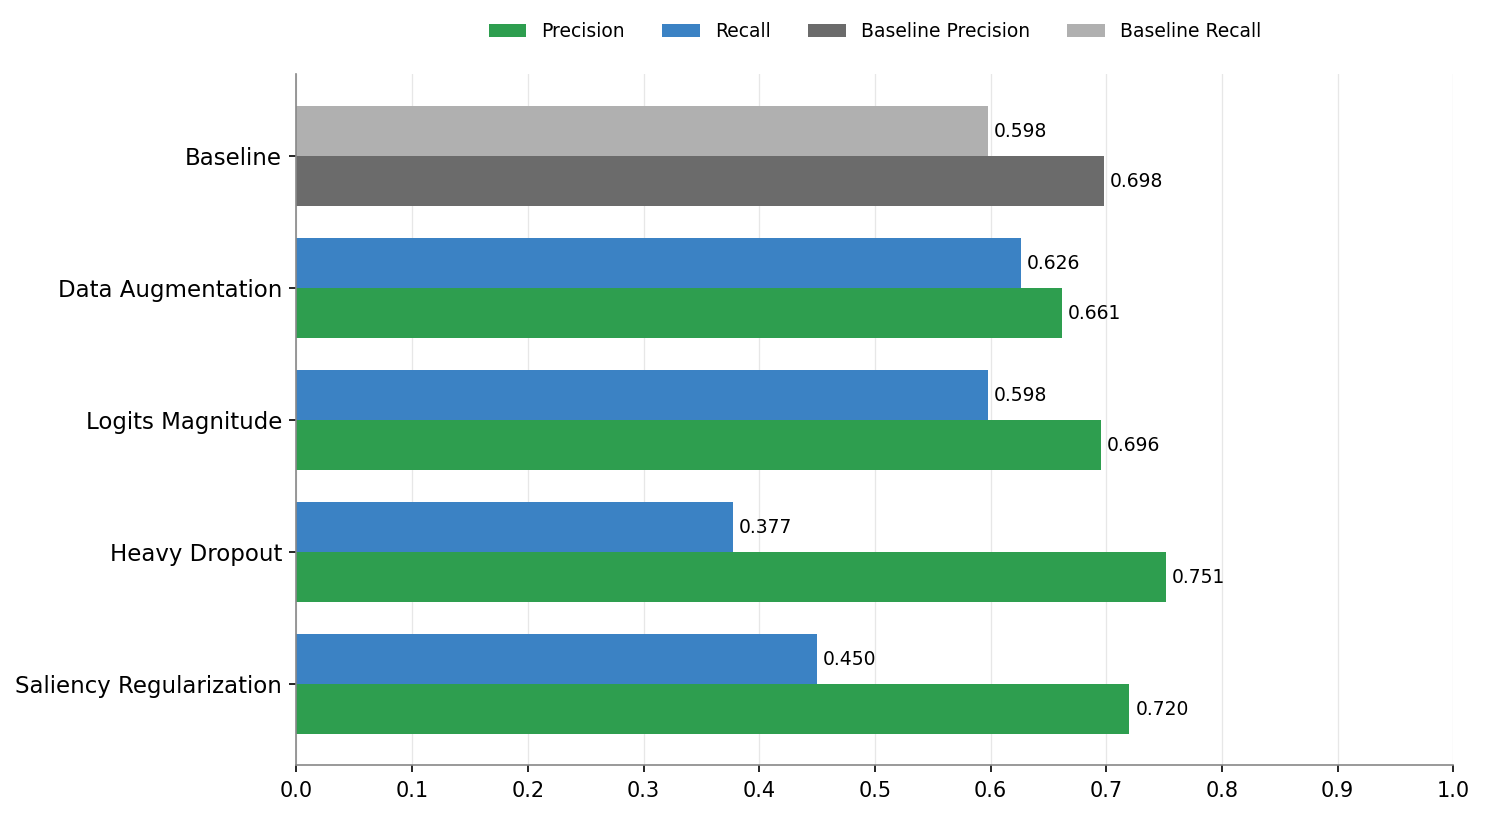

In [1]:
import matplotlib.pyplot as plt
import numpy as np

methods = ["Baseline", "Data Augmentation", "Logits Magnitude",
           "Heavy Dropout", "Saliency Regularization"]
precision = [0.6976, 0.6614, 0.6955, 0.7514, 0.72]
recall    = [0.5980, 0.6260, 0.5980, 0.3769, 0.45]

# baseline uses gray shades so it reads as a reference row
green = "#2E9E4F"
blue  = "#3B82C4"
gray_p = "#6B6B6B"
gray_r = "#B0B0B0"

precision_colors = [gray_p if m == "Baseline" else green for m in methods]
recall_colors    = [gray_r if m == "Baseline" else blue  for m in methods]

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

y = np.arange(len(methods))
bar_h = 0.38

ax.barh(y + bar_h/2, precision, height=bar_h, color=precision_colors)
ax.barh(y - bar_h/2, recall,    height=bar_h, color=recall_colors)

for i, v in enumerate(precision):
    ax.text(v + 0.005, i + bar_h/2, f"{v:.3f}", va="center", fontsize=9)
for i, v in enumerate(recall):
    ax.text(v + 0.005, i - bar_h/2, f"{v:.3f}", va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(methods, fontsize=11)
ax.invert_yaxis()

ax.set_xlim(0, 1.0)
ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.xaxis.grid(True, alpha=0.3, linewidth=0.6)
ax.set_axisbelow(True)

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color("#888")
ax.spines["bottom"].set_color("#888")

# custom legend so baseline gets its own entries
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=green,  label="Precision"),
    Patch(facecolor=blue,   label="Recall"),
    Patch(facecolor=gray_p, label="Baseline Precision"),
    Patch(facecolor=gray_r, label="Baseline Recall"),
]
ax.legend(handles=legend_handles, loc="upper center",
          bbox_to_anchor=(0.5, 1.10), ncol=4, frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("pr_bar_chart.png", dpi=200, bbox_inches="tight")
plt.show()